# Goal: Create Extended Data Fig. 3 plots

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse

import session_info
session_info.show()

/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')`

In [2]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['savefig.transparent'] = True
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['pdf.fonttype'] = 42

save_dir='/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/Summary_plots/'

# Load the integrated T cell object

In [3]:
adata=sc.read_h5ad('/rfs/project/rfs-iCNyzSAaucw/lmd76/pan_infection/datasets/pan_infection_atlas/snakemake_toolbox/out/checkpoint_objects/checkpoint_6/adata_CD8.h5ad')
adata

AnnData object with n_obs × n_vars = 1474601 × 11025
    obs: 'Compartment_prediction', 'Cross_tissue_broad', 'Cross_tissue_detailed', 'IR_VDJ_1_j_call', 'IR_VDJ_1_junction_aa', 'IR_VDJ_1_v_call', 'IR_VJ_1_j_call', 'IR_VJ_1_junction_aa', 'IR_VJ_1_v_call', 'Lindeboom_broad', 'Lindeboom_detailed', 'age', 'alternative_qc_status', 'author_annotation', 'barcode', 'batch_condition', 'cell_passed_qc', 'cell_type', 'dataset', 'dataset_id', 'disease', 'doi', 'donor', 'donor_id', 'doubletdetection_prediction', 'doubletdetection_score', 'filtered', 'group', 'infection_stage', 'infection_status', 'log1p_n_counts', 'log1p_n_genes', 'modalities', 'n_counts', 'n_counts_hb', 'n_counts_mito', 'n_counts_ribo', 'n_genes', 'obs_names_before_t_cells', 'organ', 'original_annotation', 'passed_qc', 'pathogen', 'percent_hb', 'percent_mito', 'percent_ribo', 'percent_top50', 'qc_status', 'reannotation', 'reannotation_index', 'sample', 'sample_id', 'scrublet_prediction', 'scrublet_score', 'sex', 'study', 'tissue'

In [4]:
UMAP = np.load('/rfs/project/rfs-iCNyzSAaucw/lmd76/pan_infection/datasets/pan_infection_atlas/snakemake_toolbox/out/checkpoint_objects/checkpoint_6/UMAPs/CD8_umap_neighbors_30_min_dist_1.3.npy')
adata.obsm["X_umap"] = UMAP

- Ext Data Fig. 3a

In [5]:
adata.obs['annotation_level_3'] = adata.obs['annotation_level_3'].cat.rename_categories(
    {'T CD8 SLEX': 'T CD8 PEX SELL'}
)

In [8]:
import sys
sys.path.append("/rds/project/rds-C9woKbOCf2Y/lk530/JHub/LK07_T_cell_infection_atlas/scripts/")
import sankey_KP

In [13]:
dataset_dict = {
     'BEAM':'',
     'COMBAT_2022':' (CITE-seq)',
     'Yoshida_2021':' (CITE-seq)',
     'GSE180268':'',
     'Lindeboom_2024_NP':'',
     'GSE182536':'',
     'GSE187515':'',
     'Liu_2021':' (CITE-seq)',
     'GSE217930':'',
     'Waradon_Dengue':'',
     'Lindeboom_2024_PBMCs':' (CITE-seq)',
     'GSE182159_Liver':'',
     'GSE182159_PBMCs':'',
     'GSE173231':'',
     'Reyes_2020':'',
     'Stephenson_2021':' (CITE-seq)',
     'GSE158769':' (CITE-seq)',
     'Hatje_2024_PBMCs':'',
     'Hatje_2024_Liver':'',
     'Hatje_2024_SmartSeq2':'',
     'Ren_2021_10X_3_BALF':'',
     'Ren_2021_10X_5_BALF':'',
     'Ren_2021_10X_3_PBMCs':'',
     'Ren_2021_10X_5_PBMCs':'',
     'Ren_2021_10X_3_Sputum':'',
     'HRA000190':'',
     'ESKD_2024':' (CITE-seq)',
     'GSE234241_PBMCs':'',
     'GSE234241_Liver':'',
     'GSE259231_10X_5':'',
     'GSE259231_mCEL_seq2_HBV':'',
     'GSE259231_mCEL_seq2_HCV':'',
     'GSE162097_PBMCs':'',
     'GSE162097_TDL':'',
     'GSE287808_NALT':'',
     'GSE287808_PBMCs':'',
     'GSE275633':' (CITE-seq)'
}

adata.obs['CITE']=adata.obs['dataset'].map(dataset_dict)

In [14]:
adata.obs['author_annotation']=adata.obs['author_annotation'].astype(str)
adata.obs['CITE']=adata.obs['CITE'].astype(str)

adata.obs['author_annotation_with_CITE']=(adata.obs['author_annotation']+adata.obs['CITE'])

/tmp/ipykernel_31514/159301340.py:9: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(obs[col]):


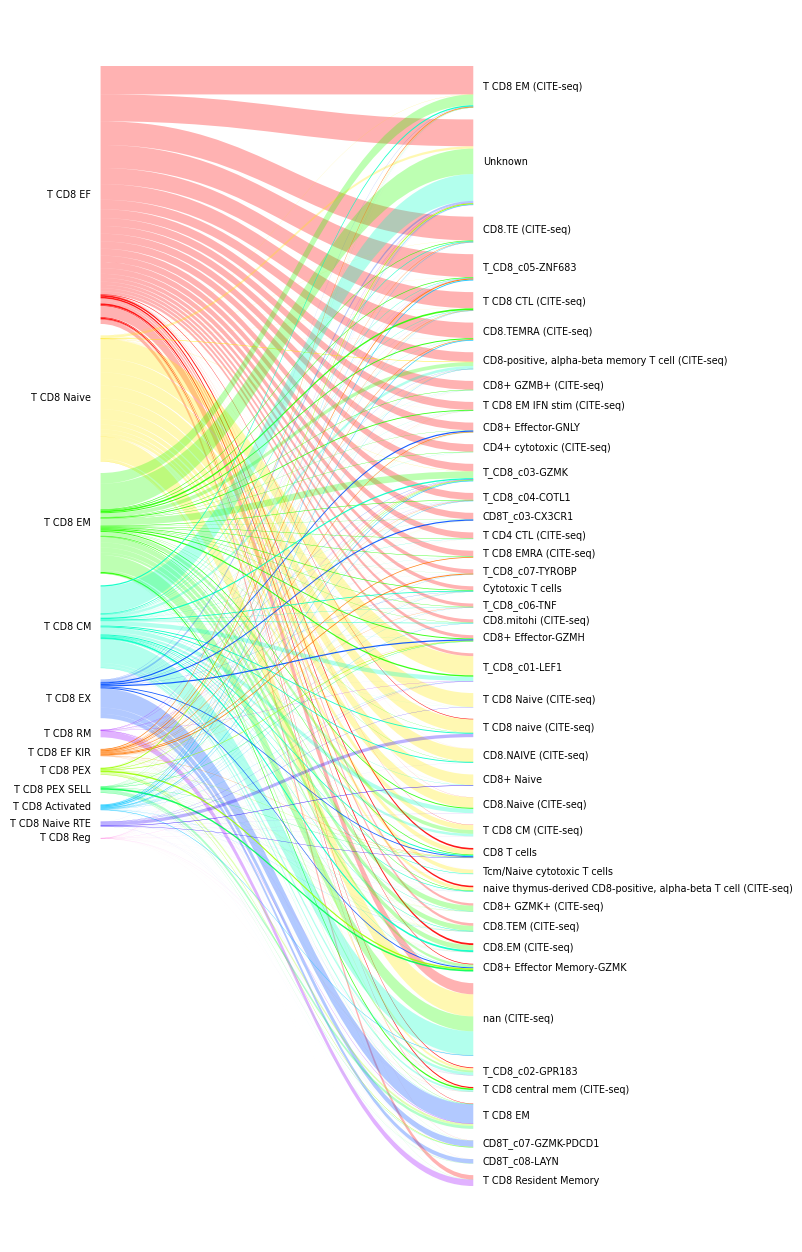

In [15]:
from sankey_KP import Sankey  # your custom Sankey class


# Copy relevant columns
obs = adata.obs[['annotation_level_3', 'author_annotation_with_CITE']].copy()

# Handle missing values
for col in ['annotation_level_3', 'author_annotation_with_CITE']:
    if pd.api.types.is_categorical_dtype(obs[col]):
        if "Unknown" not in obs[col].cat.categories:
            obs[col] = obs[col].cat.add_categories(["Unknown"])
    obs[col] = obs[col].fillna("Unknown")
    obs[col] = obs[col].replace(['nan', 'NaN', 'NAN'], "Unknown")

# Filter out rare categories instead of masking
plotting_threshold = 0.005  # 0.5%_
value_counts = obs['author_annotation_with_CITE'].value_counts(normalize=True)
keep_labels = value_counts[value_counts >= plotting_threshold].index

# Keep only cells with frequent categories
obs_filtered = obs[obs['author_annotation_with_CITE'].isin(keep_labels)].copy()

# Plot Sankey using the filtered dataframe
fig, ax = plt.subplots(figsize=(10, 16))
Sankey(
    x=obs_filtered["annotation_level_3"],
    y=obs_filtered["author_annotation_with_CITE"],
    ax=ax,
    fontsize="x-small",
    colorside="left"
).draw("left")

#plt.savefig(save_dir + "T_CD8_Sankey_author_annotation_wo_rare.pdf", dpi=200, bbox_inches="tight")

- Ext Data Fig. 3b

In [16]:
Giles_CD8_Naive_CM=pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/JHub/LK07_T_cell_infection_atlas/CD8_signatures/Giles_Immunity_2022_CD8_Naive_CM_DEGs.txt', sep='\t')

# Separate upregulated and downregulated genes
upregulated_genes = Giles_CD8_Naive_CM.loc[Giles_CD8_Naive_CM['log2FoldChange'] > 0, 'geneSymbol'].tolist()
downregulated_genes = Giles_CD8_Naive_CM.loc[Giles_CD8_Naive_CM['log2FoldChange'] < 0, 'geneSymbol'].tolist()

In [18]:
adata_Naive_CM=adata[adata.obs['annotation_level_2'].isin(['T CD8 Naive','T CD8 CM'])].copy()

In [19]:
sc.tl.score_genes(adata_Naive_CM, gene_list=upregulated_genes, score_name='Giles_CD8_Naive_score')
sc.tl.score_genes(adata_Naive_CM, gene_list=downregulated_genes, score_name='Giles_CD8_CM_score')

       'LEF1-AS1', 'ZNF667', 'AGRN',
       ...
       'PIGW', 'TMEM132E', 'RP5-1041C10.3', 'DNAJC27-AS1', 'RPL15P3', 'RPS25',
       'WNK4', 'SALL3', 'EEF1A1P11', 'RPLP2'],
      dtype='object', length=756)
       'RP11-89M16.1', 'FAM46C', 'WHSC1', 'LINC00963',
       ...
       'MPRIPP1', 'CNOT6LP1', 'NAP1L4P1', 'RP5-1024G6.8', 'C12orf44', 'ATPIF1',
       'RP11-152C15.1', 'HIST1H4I', 'Y_RNA', 'RP3-322G13.7'],
      dtype='object', length=418)


/tmp/ipykernel_31514/1067373241.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


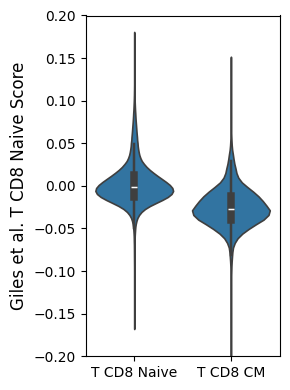

In [25]:
import seaborn as sns

df = adata_Naive_CM.obs[['annotation_level_2', 'Giles_CD8_Naive_score']].copy()

# Filter only the two categories of interest
df = df[df['annotation_level_2'].isin(['T CD8 Naive', 'T CD8 CM'])]

# Plot violin
plt.figure(figsize=(3, 4))
sns.violinplot(
    data=df,
    x='annotation_level_2',
    y='Giles_CD8_Naive_score',
    order=['T CD8 Naive', 'T CD8 CM'],
    inner='box',          # options: 'quartile', 'box', 'point', or None
    linewidth=1.2,
    palette=['#1f77b4', '#1f77b4']  # custom colors
)

plt.ylim(-0.2, 0.2)

# Labels and formatting
plt.title("", fontsize=14)
plt.xlabel("", fontsize=12)
plt.ylabel("Giles et al. T CD8 Naive Score", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()

#plt.savefig(save_dir + "T_CD8_Naive_score.pdf", dpi=200)
plt.show()

/tmp/ipykernel_31514/4257182199.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


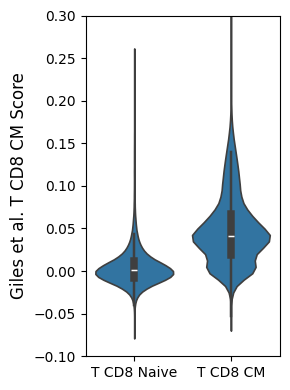

In [26]:
df = adata_Naive_CM.obs[['annotation_level_2', 'Giles_CD8_CM_score']].copy()

# Filter only the two categories of interest
df = df[df['annotation_level_2'].isin(['T CD8 Naive', 'T CD8 CM'])]

# Plot violin
plt.figure(figsize=(3, 4))
sns.violinplot(
    data=df,
    x='annotation_level_2',
    y='Giles_CD8_CM_score',
    order=['T CD8 Naive', 'T CD8 CM'],
    inner='box',          # options: 'quartile', 'box', 'point', or None
    linewidth=1.2,
    palette=['#1f77b4', '#1f77b4']  # custom colors
)

plt.ylim(-0.1, 0.3)

# Labels and formatting
plt.title("", fontsize=14)
plt.xlabel("", fontsize=12)
plt.ylabel("Giles et al. T CD8 CM Score", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()

#plt.savefig(save_dir + "T_CD8_CM_score.pdf", dpi=200)
plt.show()

- Ext Data Fig. 3c

In [52]:
adata_exh=adata[adata.obs['annotation_level_3'].isin(['T CD8 PEX SELL','T CD8 PEX','T CD8 EX'])].copy()

In [53]:
tpex_1=pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/T_CD8_PEX_SELL.csv', sep='\t', index_col=0)
tpex_1.head(50)

,p_val,avg_logFC,pct.1,pct.2,p_val_adj,cluster,gene
Dapl1,0.000000e+00,1.457759,0.494,0.056,0.000000e+00,5,Dapl1
Sell,0.000000e+00,1.420872,0.827,0.069,0.000000e+00,5,Sell
Satb1,0.000000e+00,1.186564,0.716,0.080,0.000000e+00,5,Satb1
Ccr7,0.000000e+00,0.937904,0.596,0.032,0.000000e+00,5,Ccr7
Ramp1,0.000000e+00,0.519022,0.312,0.009,0.000000e+00,5,Ramp1
Treml2,0.000000e+00,0.408470,0.288,0.014,0.000000e+00,5,Treml2
Sh3bp5,1.780000e-289,0.355510,0.284,0.018,2.880000e-285,5,Sh3bp5
Lef1,6.810000e-277,0.994231,0.761,0.156,1.100000e-272,5,Lef1
Rgs10,5.430000e-264,0.785230,0.598,0.094,8.760000e-260,5,Rgs10
Ift80,8.540000e-235,0.497396,0.331,0.032,1.380000e-230,5,Ift80


In [54]:
import re

def clean_gene_name(gene):
    # Remove trailing '1' only if it results in a match in adata_exh.var_names
    if gene not in adata_exh.var_names and gene.endswith('1'):
        cleaned = gene[:-1]
        if cleaned in adata_exh.var_names:
            return cleaned
    return gene

# Apply cleaning after uppercasing
tpex_1.index = tpex_1.index.str.upper()
tpex_1.index = [clean_gene_name(g) for g in tpex_1.index]

In [55]:
# Select top genes per cluster by avg_logFC, filtered for significance
top_genes_per_cluster = (
    tpex_1[tpex_1['p_val_adj'] < 0.05]
    .sort_values('avg_logFC', ascending=False)
    .groupby('cluster')
    .head(25)
)

# Score genes for each cluster
for cluster, group in top_genes_per_cluster.groupby('cluster'):
    gene_list = group.index.tolist()
    #tpex_1.index = tpex_1.index.str.upper()
    sc.tl.score_genes(
        adata_exh,
        gene_list=gene_list,
        score_name='T_PEX_CD62L'
    )

       'RPL152', 'RPS201', 'MT-ND21', 'TRBC1', 'RPS261', 'ARHGAP45'],
      dtype='object')


/tmp/ipykernel_31514/2835606050.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

T CD8 PEX SELL vs. T CD8 PEX: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=1.857e+08
T CD8 PEX SELL vs. T CD8 EX: Mann-Whitney-Wilcoxon test two-sided, P_val:0.000e+00 U_stat=1.197e+09


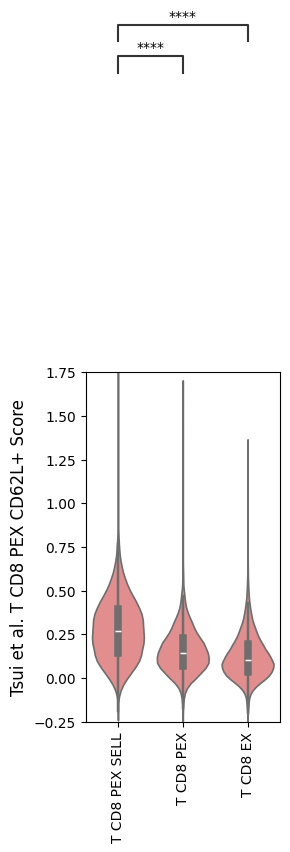

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statannotations.Annotator import Annotator

df = adata_exh.obs[["annotation_level_3", "T_PEX_CD62L"]].copy()

order = ['T CD8 PEX SELL', 'T CD8 PEX', 'T CD8 EX']

# Define pairwise comparisons
pairs = [
    ('T CD8 PEX SELL', 'T CD8 PEX'),
    ('T CD8 PEX SELL', 'T CD8 EX')
]

# Plot violin
fig, ax = plt.subplots(figsize=(3, 22))
sns.violinplot(
    data=df,
    x='annotation_level_3',
    y='T_PEX_CD62L',
    order=order,
    inner='box',
    linewidth=1.2,
    palette=['#F08080', '#F08080', '#F08080'],  # fixed: 3 colors for 3 groups
    ax=ax
)

# Add statistical annotations
annotator = Annotator(ax, pairs, data=df, x='annotation_level_3', y='T_PEX_CD62L', order=order)
annotator.configure(
    test='Mann-Whitney',        # or 't-test_ind', 'Kruskal', etc.
    text_format='star',         # or 'simple' for p-values, 'star' for asterisks
    loc='outside',              # or 'inside'
    verbose=2
)
annotator.apply_and_annotate()

plt.ylim(-0.25, 1.75)
plt.title("", fontsize=14)
plt.xlabel("", fontsize=12)
plt.ylabel("Tsui et al. T CD8 PEX CD62L+ Score", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
#plt.savefig(save_dir + "T_CD8_PEX_CD62Lpos_score.pdf", dpi=200)
plt.show()

- Ext Data Fig. 3d

In [58]:
work_dir='/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/Multi_milo/Manuscript_final/'

In [59]:
from __future__ import annotations
from pathlib import Path
from typing import Optional, Sequence, Dict, Tuple, Union
import os
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def plot_multi_milo(
    compare_variable: str,
    annotation: str,
    milo_dir: Union[str, Path],
    exp_df: Union[str, Path, pd.DataFrame],
    cell_type: str = "CD4",
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    group_of_interest: Optional[str] = None,
    only_show_group_of_interest: bool = False,
    savedir: Optional[Union[str, Path]] = None,
    significant_only: bool = True,
    sig_thresh: float = 0.20,
    sig_thresh_strict: float = 0.10,
    sig_star: bool = False,
    blood_only: bool = False,
    ignore_groups: Optional[Sequence[str]] = None,
    add_filter: Optional[Tuple[str, str]] = None,
    drop_duplicates: bool = False,
    df_filter_exclude_annotation: Sequence[str] = ("Mixed",),
    tissue_colors: Optional[Dict[str, str]] = None,
    group_palette: Optional[Sequence] = None,
    cmap: str = "bwr",
    center: float = 0.0,
    col_cluster: bool = True,
    row_cluster: bool = True,
    row_order: Optional[Sequence] = None,
    col_order: Optional[Sequence[str]] = None,
    figure_size: Tuple[int, int] = None,
    return_objects: bool = True,
) -> Optional[Tuple[sns.matrix.ClusterGrid, pd.DataFrame, pd.DataFrame]]:
    """
    Plot a Milo-style clustermap of per-experiment cell-state enrichment/depletion.

    Row labels show the pathogen name derived from the `group_1` column of exp_df,
    with underscores replaced by spaces for readability:
      "Plasmodium_falciparum" -> "Plasmodium falciparum"
      "SARS_CoV_2"            -> "SARS CoV 2"
      "HIV_acute"             -> "HIV acute"

    row_order : sequence, optional
        Custom order for rows (experiment IDs). If provided, disables row clustering.
    col_order : sequence of str, optional
        Custom order for columns (nhood_annotation). If provided, disables column clustering.
    cell_type : str, optional
        Cell type to load results for. Either "CD4" or "CD8". Default is "CD4".
    vmin : float, optional
        Minimum value for colormap scaling. If None, uses data min.
    vmax : float, optional
        Maximum value for colormap scaling. If None, uses data max.
    """
    logging.getLogger(__name__).setLevel(logging.INFO)

    milo_dir = Path(milo_dir)
    summary_dir = milo_dir / annotation

    if isinstance(exp_df, (str, Path)):
        experiment_df = pd.read_csv(exp_df)
    else:
        experiment_df = exp_df.copy()

    # Basic input checks
    required_cols = {"id", "compare_variable", "group_1", "group_2"}
    missing = required_cols - set(experiment_df.columns)
    if missing:
        raise ValueError(f"exp_df is missing required columns: {sorted(missing)}")

    experiment_df = experiment_df[experiment_df["compare_variable"] == compare_variable].copy()

    if drop_duplicates and "subset_condition" in experiment_df.columns:
        experiment_df = experiment_df.drop_duplicates(subset="subset_condition")

    if add_filter is not None:
        key, val = add_filter
        if key not in experiment_df.columns:
            raise KeyError(f"add_filter key '{key}' not found in exp_df columns")
        experiment_df = experiment_df[experiment_df[key] == val]

    if only_show_group_of_interest:
        experiment_df = experiment_df[
            experiment_df["group_1"].eq(group_of_interest) | experiment_df["group_2"].eq(group_of_interest)
        ]

    if ignore_groups:
        ig = set(ignore_groups)
        experiment_df = experiment_df[
            ~experiment_df["group_1"].isin(ig) & ~experiment_df["group_2"].isin(ig)
        ]

    # Build id -> pathogen label mapping directly from group_1 in experiment_df.
    # Underscores are replaced with spaces for readability.
    # e.g. "Plasmodium_falciparum" -> "Plasmodium falciparum"
    #      "SARS_CoV_2"            -> "SARS CoV 2"
    #      "HIV_acute"             -> "HIV acute"
    #      "Bacterial_infection"   -> "Bacterial infection"
    id_to_label: Dict[str, str] = {
        row["id"]: str(row["group_1"]).replace("_", " ")
        for _, row in experiment_df.iterrows()
    }

    all_results = []
    all_results_full = []
    selected_meta_rows = []

    if tissue_colors is None:
        tissue_colors = {"PBMCs": "firebrick", "non-PBMCs": "#999999"}

    for _, row in experiment_df.iterrows():
        eid = row["id"]
        summary_path = summary_dir / f"results_{cell_type}_{eid}.csv"
        if not summary_path.exists():
            logging.warning(f"Missing file: {summary_path.name}")
            continue

        df = pd.read_csv(summary_path)
        missing_cols = {"nhood_annotation", "logFC", "SpatialFDR"} - set(df.columns)
        if missing_cols:
            logging.warning(f"{summary_path.name} missing columns: {sorted(missing_cols)}; skipping.")
            continue

        df["experiment_id"] = eid

        # Flip logFC to ensure consistent interpretation for group_of_interest.
        flipped = False
        if group_of_interest is not None:
            if group_of_interest == "Healthy":
                if row["group_1"] == group_of_interest:
                    df["logFC"] = -df["logFC"]
                    flipped = True
            else:
                if row["group_2"] == group_of_interest:
                    df["logFC"] = -df["logFC"]
                    flipped = True

        meta_row = row.copy()
        meta_row["id"] = eid
        if flipped:
            meta_row["group_1"], meta_row["group_2"] = meta_row["group_2"], meta_row["group_1"]
        selected_meta_rows.append(meta_row)

        if significant_only:
            df = df[df["SpatialFDR"] < sig_thresh].copy()

        if df_filter_exclude_annotation:
            df = df[~df["nhood_annotation"].isin(df_filter_exclude_annotation)]

        if df.empty:
            continue

        all_results.append(df[["experiment_id", "nhood_annotation", "logFC"]])
        if sig_star:
            all_results_full.append(df[["experiment_id", "nhood_annotation", "logFC", "SpatialFDR"]])

    if not all_results:
        logging.warning("No results to plot after filtering; nothing to do.")
        return None if not return_objects else (None, pd.DataFrame(), pd.DataFrame())

    # Build matrix and meta
    results_df = pd.concat(all_results, ignore_index=True)
    matrix = (
        results_df.pivot(index="experiment_id", columns="nhood_annotation", values="logFC")
        .fillna(0.0)
    )
    # Drop rows that are all zeros (no retained neighborhoods for that experiment)
    matrix = matrix.loc[~(matrix == 0).all(axis=1)]
    if matrix.empty:
        logging.warning("LogFC matrix is empty after zero-row removal; nothing to plot.")
        return None if not return_objects else (None, matrix, pd.DataFrame())

    # Apply custom ordering if provided
    if row_order is not None:
        valid_rows = [r for r in row_order if r in matrix.index]
        if not valid_rows:
            logging.warning("No valid row_order IDs found in matrix; ignoring row_order")
        else:
            matrix = matrix.loc[valid_rows]
            row_cluster = False

    if col_order is not None:
        valid_cols = [c for c in col_order if c in matrix.columns]
        if not valid_cols:
            logging.warning("No valid col_order annotations found in matrix; ignoring col_order")
        else:
            matrix = matrix[valid_cols]
            col_cluster = False

    meta = pd.DataFrame(selected_meta_rows).set_index("id").loc[matrix.index].copy()

    # --- Color mapping for groups ---
    group_vals = pd.unique(meta[["group_1", "group_2"]].values.ravel("K"))
    group_vals = [g for g in group_vals if pd.notna(g)]
    if "Healthy" in group_vals:
        group_vals = ["Healthy"] + sorted([g for g in group_vals if g != "Healthy"])
    else:
        group_vals = sorted(group_vals)

    if group_palette is None:
        group_palette = sns.color_palette("tab20", n_colors=max(len(group_vals), 3))
    group_colors = dict(zip(group_vals, group_palette))

    row_colors = pd.DataFrame(
        {
            "Group 1": meta["group_1"].map(group_colors),
            "Group 2": meta["group_2"].map(group_colors),
        },
        index=matrix.index,
    )

    if figure_size is not None:
        figsize = figure_size
    else:
        if matrix.shape[0] < 5:
            figsize = (7, 6)
        else:
            figsize = (10, 10)

    g = sns.clustermap(
        matrix,
        vmin=vmin,
        vmax=vmax,
        row_colors=row_colors,
        cmap=cmap,
        center=center,
        figsize=figsize,
        xticklabels=True,
        yticklabels=False,
        col_cluster=col_cluster,
        row_cluster=row_cluster,
        cbar_kws={'label': 'logFC'},
        cbar_pos=(1.25, 0.2, 0.03, 0.3),
    )

    # Optional significance overlay
    if sig_star and all_results_full:
        full_df = pd.concat(all_results_full, ignore_index=True)

        full_matrix = (
            full_df.pivot(index="experiment_id", columns="nhood_annotation", values="logFC")
            .reindex(index=matrix.index, columns=matrix.columns)
        )
        fdr = full_df.pivot(index="experiment_id", columns="nhood_annotation", values="SpatialFDR")
        fdr = fdr.reindex_like(full_matrix)

        sig_mask_loose = fdr < sig_thresh
        sig_mask_strict = fdr < sig_thresh_strict

        if row_order is not None and col_order is not None:
            row_order_plot = [r for r in row_order if r in matrix.index]
            col_order_plot = [c for c in col_order if c in matrix.columns]
        elif row_order is not None:
            row_order_plot = [r for r in row_order if r in matrix.index]
            col_order_plot = [full_matrix.columns[i] for i in g.dendrogram_col.reordered_ind]
        elif col_order is not None:
            row_order_plot = [full_matrix.index[i] for i in g.dendrogram_row.reordered_ind]
            col_order_plot = [c for c in col_order if c in matrix.columns]
        else:
            row_order_plot = [full_matrix.index[i] for i in g.dendrogram_row.reordered_ind]
            col_order_plot = [full_matrix.columns[i] for i in g.dendrogram_col.reordered_ind]

        ax = g.ax_heatmap
        for i, rid in enumerate(row_order_plot):
            for j, cid in enumerate(col_order_plot):
                if pd.notna(sig_mask_loose.loc[rid, cid]) and sig_mask_loose.loc[rid, cid]:
                    mark = "*" if (pd.notna(sig_mask_strict.loc[rid, cid]) and sig_mask_strict.loc[rid, cid]) else "°"
                    ax.text(j + 0.5, i + 0.5, mark, ha="center", va="center", color="black", fontsize=12)



    # --- Y-axis labels: use pathogen name (from group_1) instead of experiment ID ---
    if row_order is not None:
        reordered_index = [r for r in row_order if r in matrix.index]
    else:
        reordered_index = list(matrix.index[g.dendrogram_row.reordered_ind])

    reordered_labels = [id_to_label.get(eid, str(eid)) for eid in reordered_index]

    g.ax_heatmap.set_yticks(np.arange(len(reordered_labels)) + 0.5)
    g.ax_heatmap.set_yticklabels(reordered_labels)

    plt.suptitle(f"FDR: {sig_thresh} > ° > {sig_thresh_strict} > *, {annotation}", y=1.05)
    plt.tight_layout()

    if savedir is not None:
        savedir = Path(savedir)
        g.savefig(savedir, bbox_inches="tight")

    plt.show()

/tmp/ipykernel_31514/683427984.py:293: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


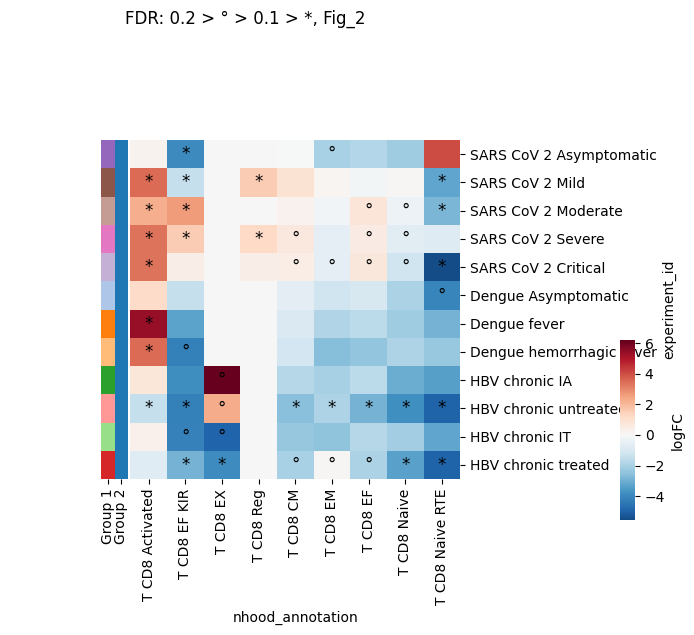

In [60]:
custom_row_order=[0,1,2,3,4,5,6,7,11,9,10,8]

custom_col_order=['T CD8 Activated','T CD8 EF KIR','T CD8 EX','T CD8 Reg','T CD8 CM','T CD8 EM','T CD8 EF','T CD8 Naive','T CD8 Naive RTE']

plot_multi_milo(compare_variable='severity_stage_detail2',
                milo_dir=work_dir,
                cell_type='CD8',
                significant_only=False,
                figure_size=(5,6),
                annotation='Fig_2',
                exp_df=work_dir+'milo_experiment_plan_CD4_fig2.csv',
                sig_star=True,
                row_order=custom_row_order,
                col_order=custom_col_order,
                cmap='RdBu_r',
                sig_thresh=0.2)

- Ext Data Fig. 3e

In [61]:
bdata=sc.read_h5ad('/rds/project/rds-C9woKbOCf2Y/mgi21/vaccination_atlas/datasets/vacc_atl_ds_04/vacc_atl_ds_04_ECCITE_TCR.h5ad')
bdata

AnnData object with n_obs × n_vars = 31396 × 16640
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'VLNDILSRL', 'YLQPRTFLL', 'RLNEVAKNL', 'NLNESLIDL', 'SPRRARSVA', 'Neg.HLA', 'Neg.general', 'sample', 'CTgene', 'CTnt', 'CTaa', 'CDR3a', 'CDR3b', 'CTstrict', 'Frequency', 'cloneType', 'celltype', 'Dex', 'Dex_clone', 'antigen_module_score'
    var: 'gene_ids', 'feature_types'
    uns: 'conversion_info', 'protein_assay', 'protein_names'
    obsm: 'X_integrated.adt.pca', 'X_integrated.rna.pca', 'X_tcr.dist', 'X_wnn.tcr.umap', 'protein_counts', 'protein_expression'
    layers: 'counts'

In [62]:
bdata.X=bdata.layers['counts']
sc.pp.normalize_per_cell(bdata, 1e4) 
sc.pp.log1p(bdata)

/tmp/ipykernel_31514/437983099.py:2: FutureWarning: The specified parameters ('counts_per_cell_after',) are no longer positional. Please specify them like `counts_per_cell_after=10000.0`
  sc.pp.normalize_per_cell(bdata, 1e4)


In [64]:
import celltypist
model = '/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/CellTypist/Infection_atlas_T_CD8_annotation_level_3.pkl'
predictions = celltypist.annotate(bdata, model = model, majority_voting = True)

🔬 Input data has 31396 cells and 16640 genes
🔗 Matching reference genes in the model
🧬 1321 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


In [65]:
bdata = predictions.to_adata()

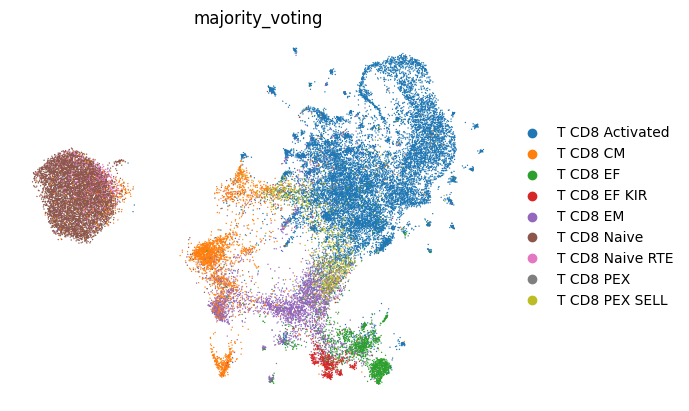

In [69]:
sc.pl.embedding(bdata, basis='X_wnn.tcr.umap', color=['majority_voting'], frameon=False, show=False)
#plt.savefig(save_dir+'T_CD8_Zhang_mRNA_vaccine_majority_voting_UMAP.pdf')
plt.show()

- Ext Data Fig. 3f

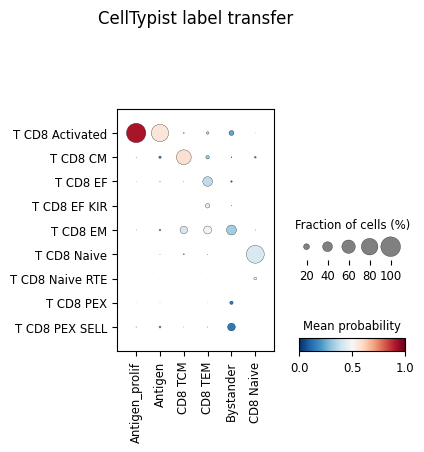

In [68]:
celltypist.dotplot(predictions, use_as_reference = 'celltype', use_as_prediction = 'majority_voting', show=False)
#plt.savefig(save_dir + 'T_CD8_Zhang_mRNA_vaccine_celltypist_dotplot.pdf', dpi=200, bbox_inches='tight')
plt.show()

- Ext Data Fig. 3g

In [75]:
custom_order=[ 
 'T CD8 Activated',
 'T CD8 CM',
 'T CD8 EF',
 'T CD8 EF KIR',
 'T CD8 EM',
 'T CD8 Naive',
 'T CD8 Naive RTE',
 'T CD8 PEX',
 'T CD8 PEX SELL',
]

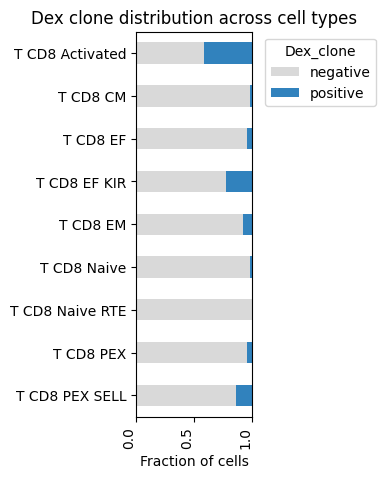

In [76]:
df = bdata.obs[['majority_voting', 'Dex_clone']].copy()

# Remove unused categories if categorical
df['majority_voting'] = df['majority_voting'].cat.remove_unused_categories()
df['Dex_clone'] = df['Dex_clone'].cat.remove_unused_categories()

# Count cells per combination
count_df = df.groupby(['majority_voting', 'Dex_clone']).size().reset_index(name='cell_count')

# Pivot to have Dex_clone as columns
pivot_df = count_df.pivot(index='majority_voting', columns='Dex_clone', values='cell_count').fillna(0)

# Convert counts to relative frequencies per cell type
rel_df = pivot_df.div(pivot_df.sum(axis=1), axis=0)

# Reindex rows according to custom order and drop rows not in custom_order
rel_df = rel_df.reindex([x for x in custom_order[::-1] if x in rel_df.index])

# Drop columns that are all zero (unused Dex_clone categories)
rel_df = rel_df.loc[:, (rel_df > 0).any(axis=0)]

ax = rel_df.plot(kind='barh', stacked=True, figsize=(1.5, 5), colormap='tab20c_r')

plt.ylabel("")
plt.xlabel("Fraction of cells")
plt.title("Dex clone distribution across cell types")
plt.xlim(0, 1)  # fix x-axis to exactly 0-1
plt.xticks(rotation=90, ha='right')
plt.legend(title='Dex_clone', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
#plt.savefig(save_dir + 'T_CD8_Zhang_mRNA_vaccine_majority_voting_Dex_clone_distribution.pdf')
plt.show()